In [1]:
import mplhep
mplhep.style.use('ROOT')
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import hist
import uproot

class HistFile:
    def __init__(self, fp, ana, **kwargs):
        self._file = uproot.open(fp, **kwargs)
        self._ana = ana
        self._ana_dir = self._file[self._ana]

    def keys(self):
        return [
            key.removeprefix(f'{self._ana}_').removesuffix(';1')
            for key in self._ana_dir.keys()
        ]

    def __getitem__(self, item):
        if item in self._ana_dir:
            return self._ana_dir[item]
        if item in self._file:
            return self._file[item]
        return self._ana_dir[f'{self._ana}_{item}']

In [2]:
f = HistFile('hist_track_ana_100.root', 'TrackAnalyzer')

In [3]:
f.keys()

['event_tracks',
 'n_hits',
 'clean_event_tracks',
 'impact_point',
 'leadtrk_impact_point',
 'reco_momentum',
 'sim_momentum',
 'reco_leadtrk_momentum',
 'reco_leadtrk_momentum_neg_charge',
 'reco_leadtrk_momentum_impact_cuts',
 'leadtrk_reco_vs_sim_momentum',
 'leadtrk_reco_vs_sim_momentum_impact_cuts',
 'leadtrk_reco_vs_sim_momentum_nhits_10_impact_cuts',
 'leadtrk_reco_vs_sim_momentum_nhits_10',
 'leadtrk_chi2',
 'leadtrk_chi2_nhits_10',
 'leadtrk_chi2_nhits_10_impact_cuts',
 'leadtrk_all_req_reduced_chi2',
 'EScorePlane_momentum',
 'leading_electron_energy',
 'leadtrk_reco_nhits_10_impact_cuts_vs_Energy_Estimate_R2',
 'difference_R2',
 'energy_diff_vs_chi2_R2',
 'leadtrk_reco_nhits_10_impact_cuts_vs_Energy_Estimate_R5',
 'difference_R5',
 'energy_diff_vs_chi2_R5',
 'leadtrk_reco_nhits_10_impact_cuts_vs_Energy_Estimate_R10',
 'difference_R10',
 'energy_diff_vs_chi2_R10']

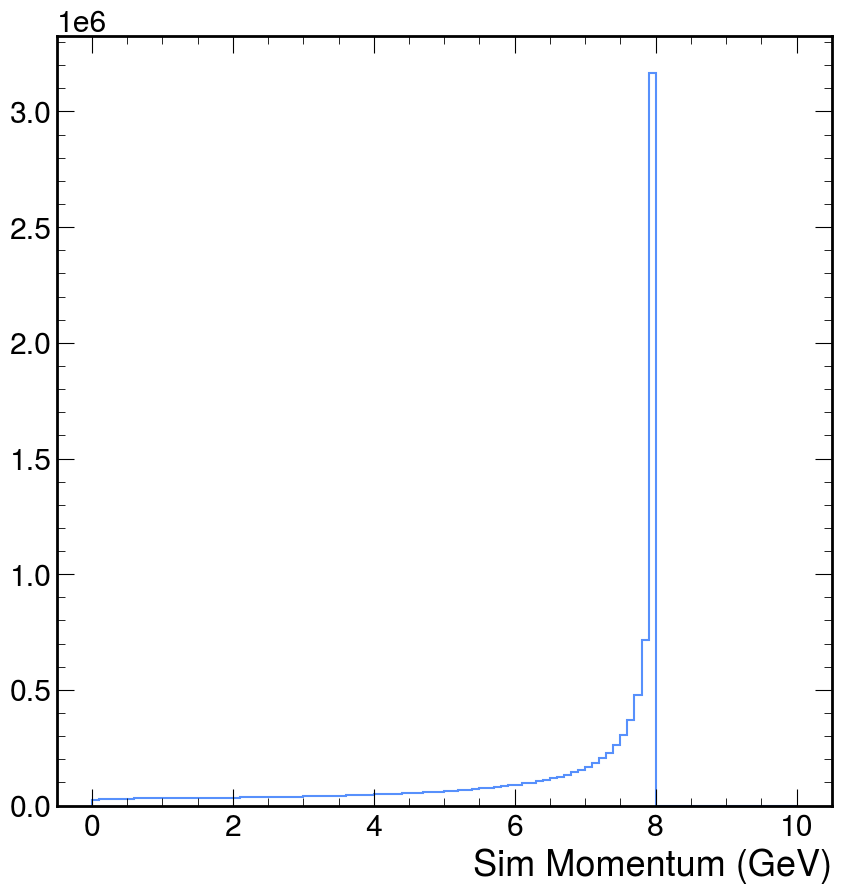

In [56]:
g = f['sim_momentum'].to_hist().plot()
#plt.savefig("reco_momentum.jpg")

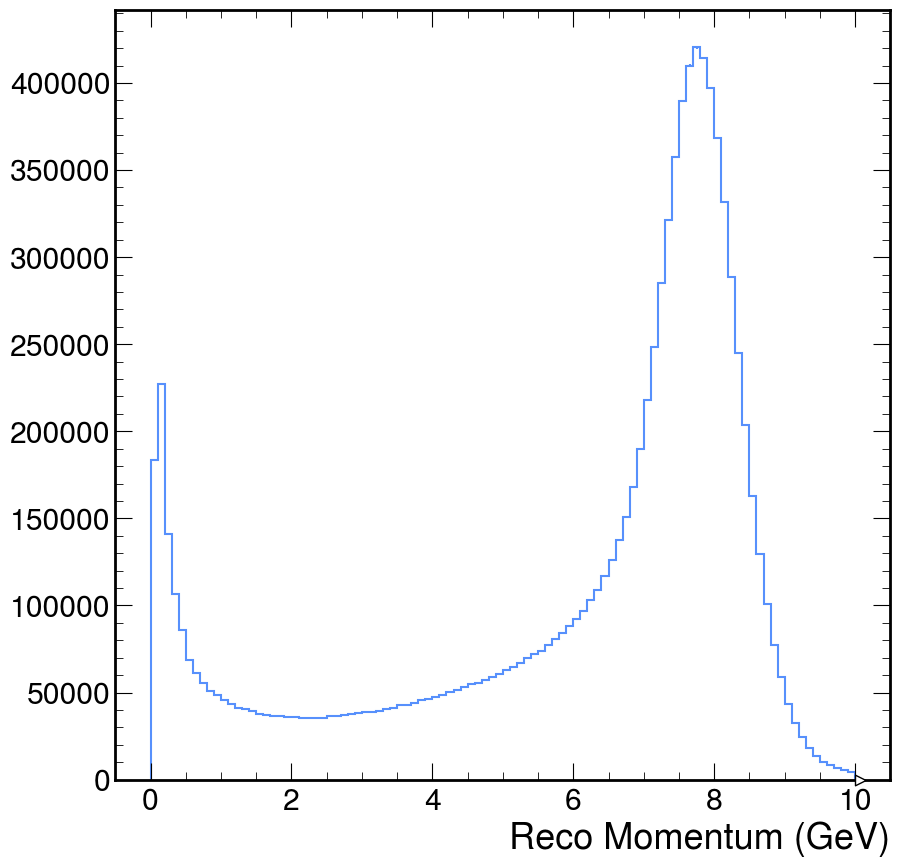

In [57]:
g = f['reco_momentum'].to_hist().plot()
#plt.savefig("reco_momentum.jpg")

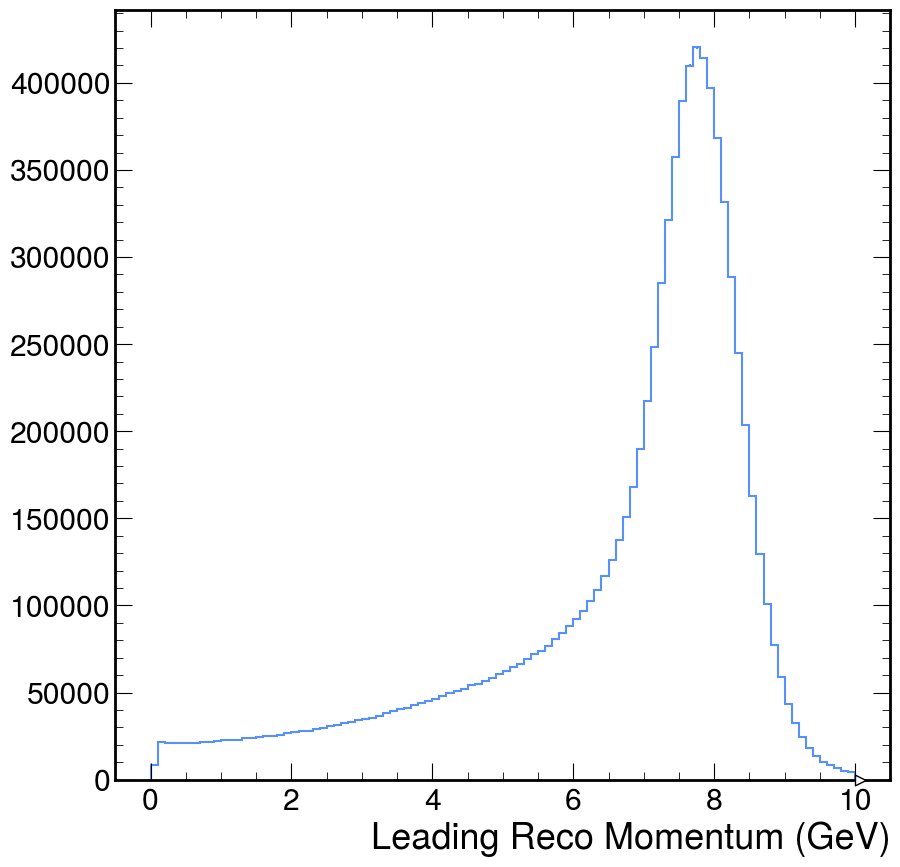

In [58]:
g = f['reco_leadtrk_momentum'].to_hist().plot()
#plt.savefig("leadtrk_reco_momentum.jpg")

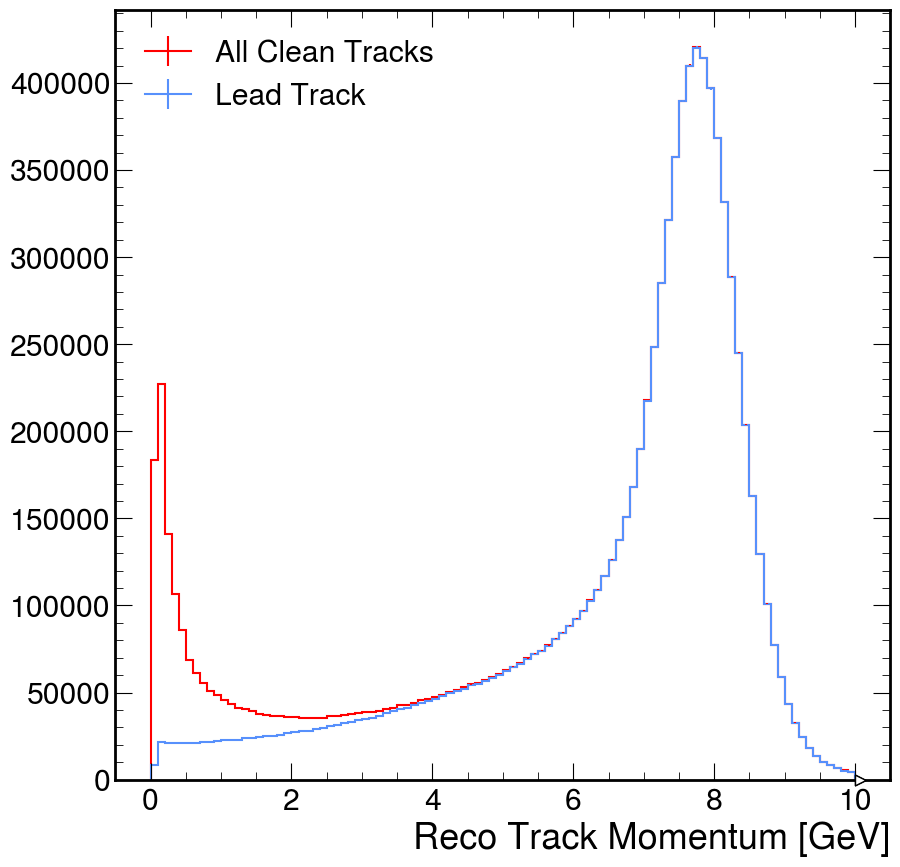

In [59]:
hh = f['reco_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "All Clean Tracks")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Lead Track")
plt.legend(loc='best')
plt.xlabel('Reco Track Momentum [GeV]')
#plt.ylim(0,5000)
#plt.yscale("log")
plt.savefig("10M_clean_vs_leadtrk_reco_1D.jpg")

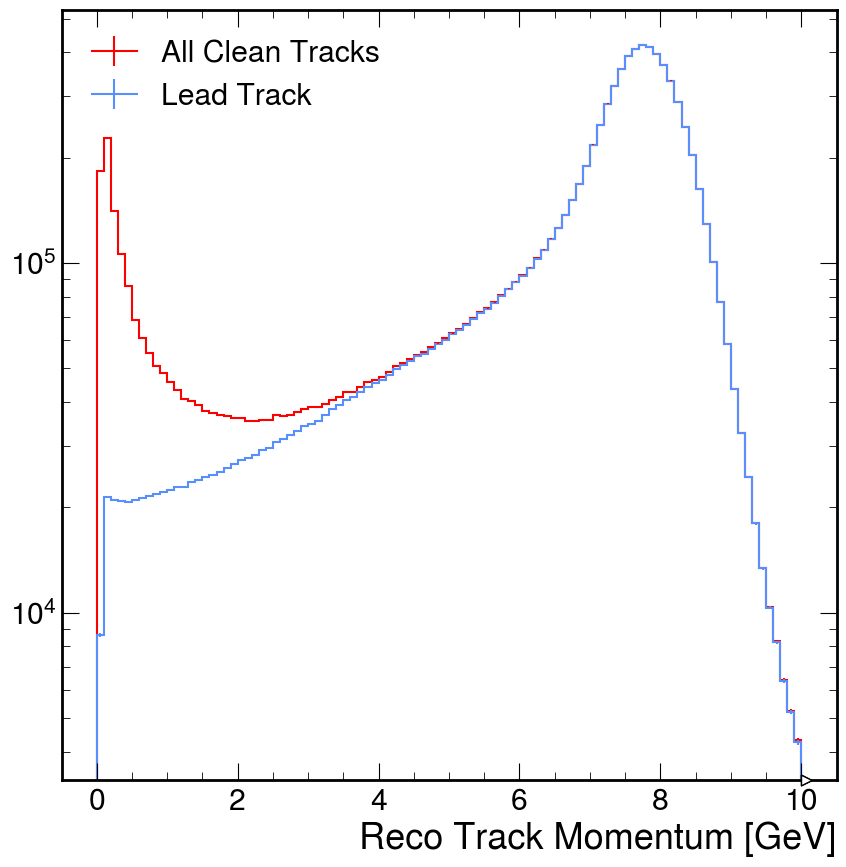

In [60]:
hh = f['reco_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "All Clean Tracks")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Lead Track")
plt.legend(loc='best')
plt.xlabel('Reco Track Momentum [GeV]')
#plt.ylim(0,5000)
plt.yscale("log")
plt.savefig("10M_clean_vs_leadtrk_reco_1D_log.jpg")

90.0 3.5999999999999996
75.0 6.0


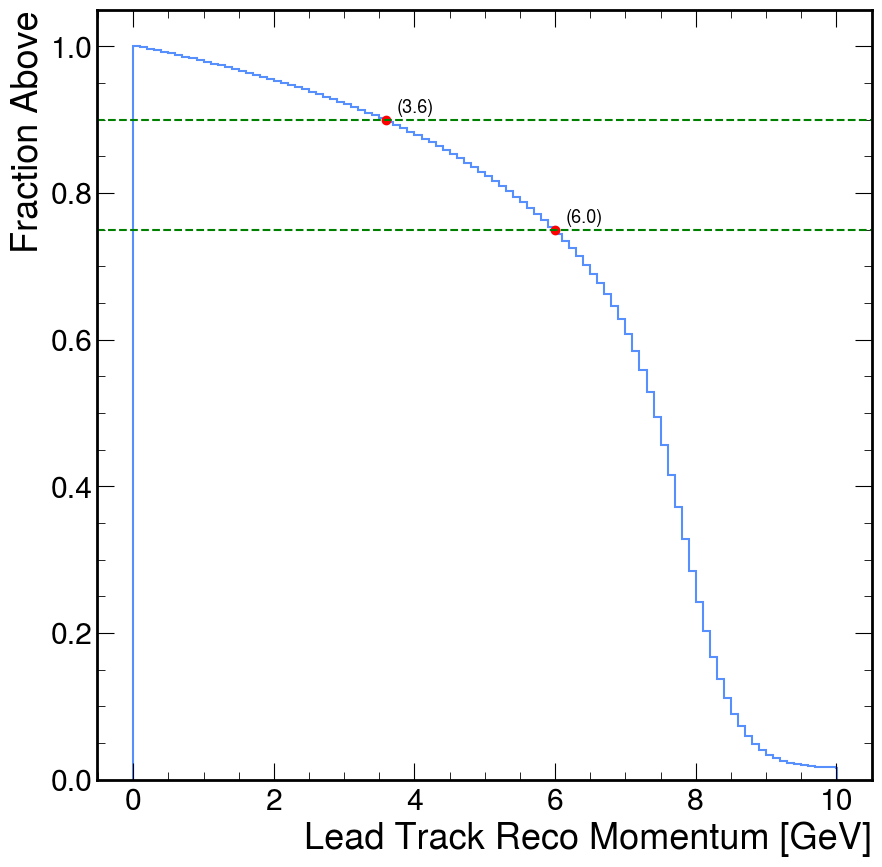

In [61]:
h = f['reco_leadtrk_momentum'].to_hist()
import numpy as np

fraction_above = np.flip(np.cumsum(np.flip(h.values(flow=True))))/np.sum(h.values(flow=True))
momentum = np.concatenate(([h.axes[0].edges[0]-0.01],h.axes[0].edges,[h.axes[0].edges[-1]+0.01]))

mplhep.histplot(fraction_above, bins = momentum)

for thresh in (0.9, 0.75):
    first_above = momentum[np.argmin(fraction_above>thresh)]
    print(100*thresh, first_above)
    #plt.annotate(f'(90%, {first_above:.2f} GeV)', (0.9,first_above), va='bottom', ha='left')
    #plt.axvline(first_above, label = " str(first_above) +, color = "r")
    plt.plot(first_above,thresh,'ro') 
    plt.text(first_above+0.15, thresh+0.01, f"({np.round(first_above,decimals=3)})", fontsize=13)
    plt.axhline(thresh, color = "g", linestyle='--')

plt.xlabel('Lead Track Reco Momentum [GeV]')
plt.ylabel('Fraction Above')
#plt.legend(loc= "best")
plt.savefig("cumsum_plot.jpg")

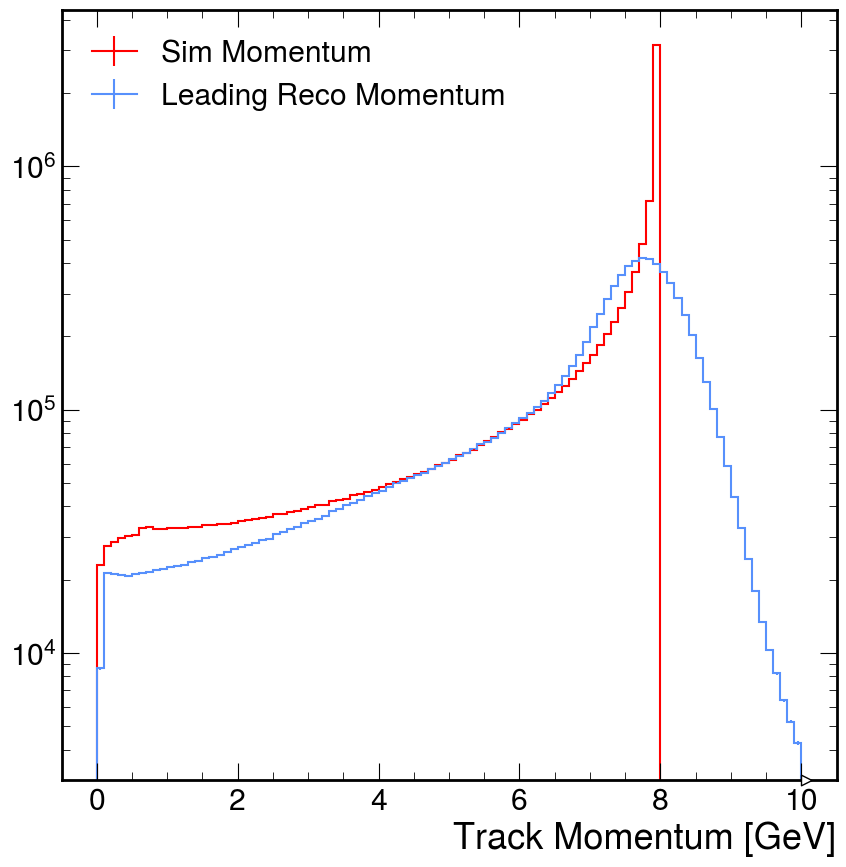

In [38]:
hh = f['sim_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "Sim Momentum")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Leading Reco Momentum")
plt.legend(loc='best')
plt.xlabel('Track Momentum [GeV]')
plt.yscale("log")
plt.savefig("10M_sim_vs_lead_reco_1D-log.jpg")

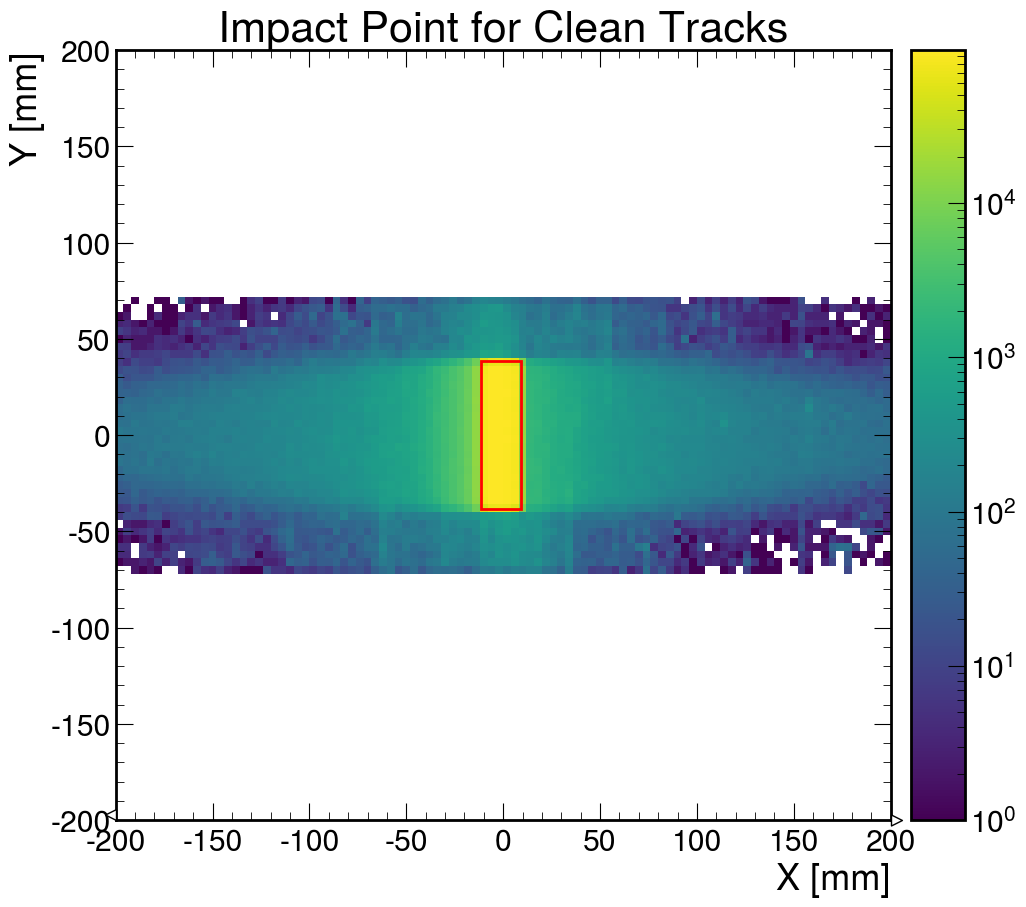

In [16]:
f['impact_point'].to_hist().plot(cmin=1,norm='log')
ax = plt.gca()
plt.title("Impact Point for Clean Tracks")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.savefig("impact_point_clean_tracks_BEAMSPOT_10M.jpg")

In [ ]:
h=f['leadtrk_impact_point'].to_hist()
h_rebin = h[{0:hist.rebin(0.5),1:hist.rebin(0.5)}]
ax = plt.gca()
plt.title("Impact Point for Leading Tracks")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)
h_rebin.plot(cmin=1)

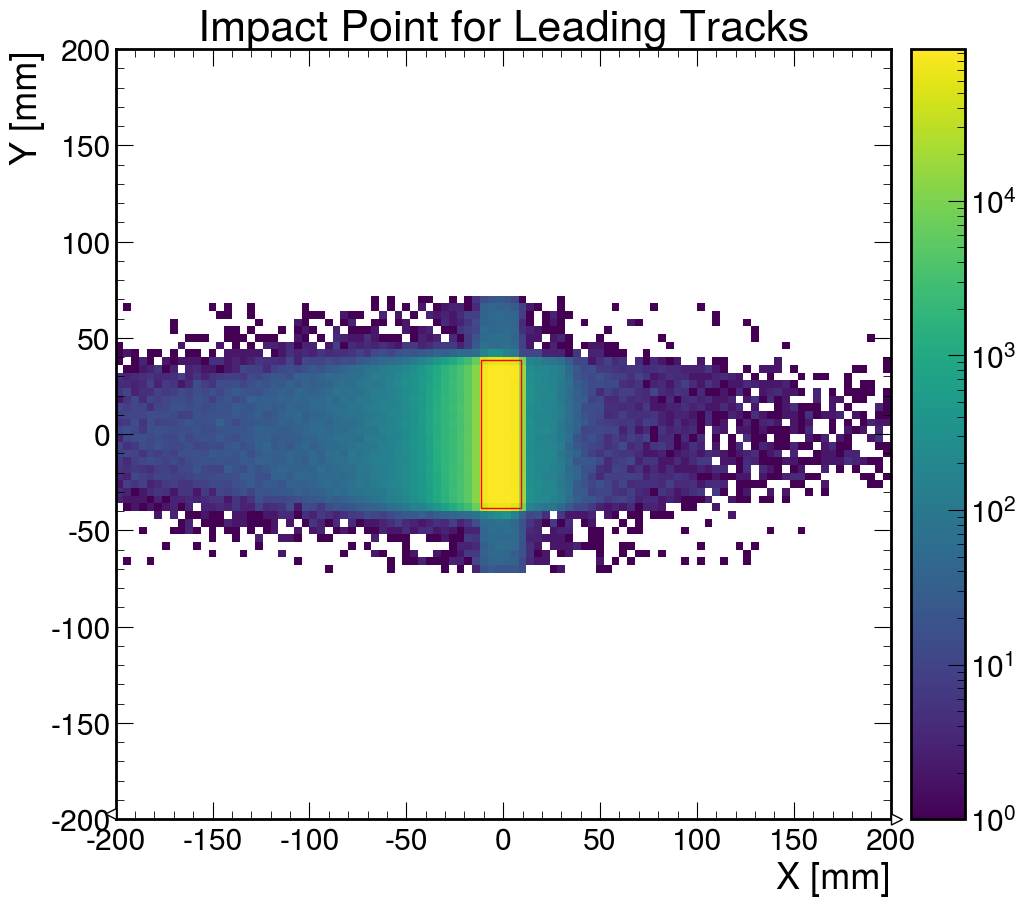

In [17]:
f['leadtrk_impact_point'].to_hist().plot(cmin=1,norm='log')
ax = plt.gca()
plt.title("Impact Point for Leading Tracks")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)
#plt.show()
plt.savefig("leadtrk_tracks_impact_point_10M.jpg")

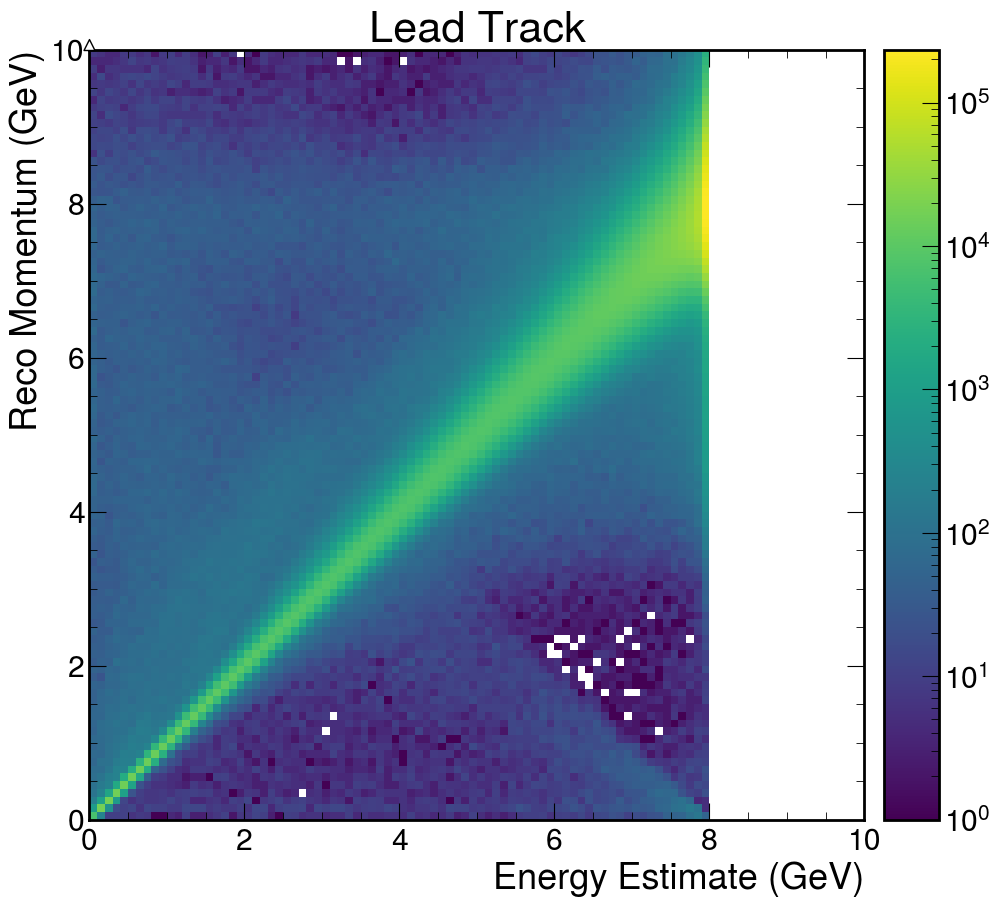

In [21]:
h=f['leadtrk_reco_vs_sim_momentum'].to_hist()
#h_rebin = h[{0:hist.rebin(),1:hist.rebin(5)}]
plt.title("Lead Track")
h.plot(cmin=1, norm='log')
#plt.show()
plt.savefig("leadtrk_reco_vs_sim_momentum-10M.jpg")

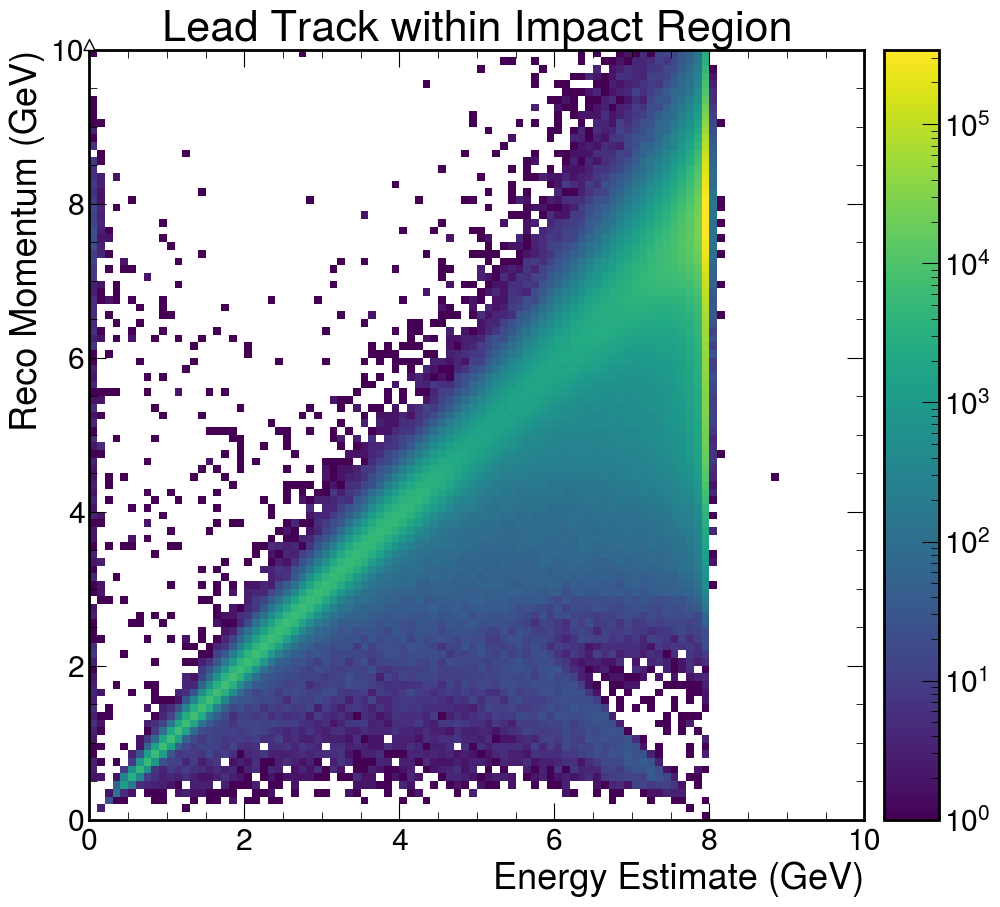

In [22]:
h=f['leadtrk_reco_nhits_10_impact_cuts_vs_Energy_Estimate_R2'].to_hist()
#h_rebin = h[{0:hist.rebin(),1:hist.rebin(5)}]
plt.title("Lead Track within Impact Region")
h.plot(cmin=1, norm='log')
#plt.show()
plt.savefig("all_reqs_leadtrk_reco_vs_energy_estimate_R2-10M.jpg")

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fad7fbc8d10>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

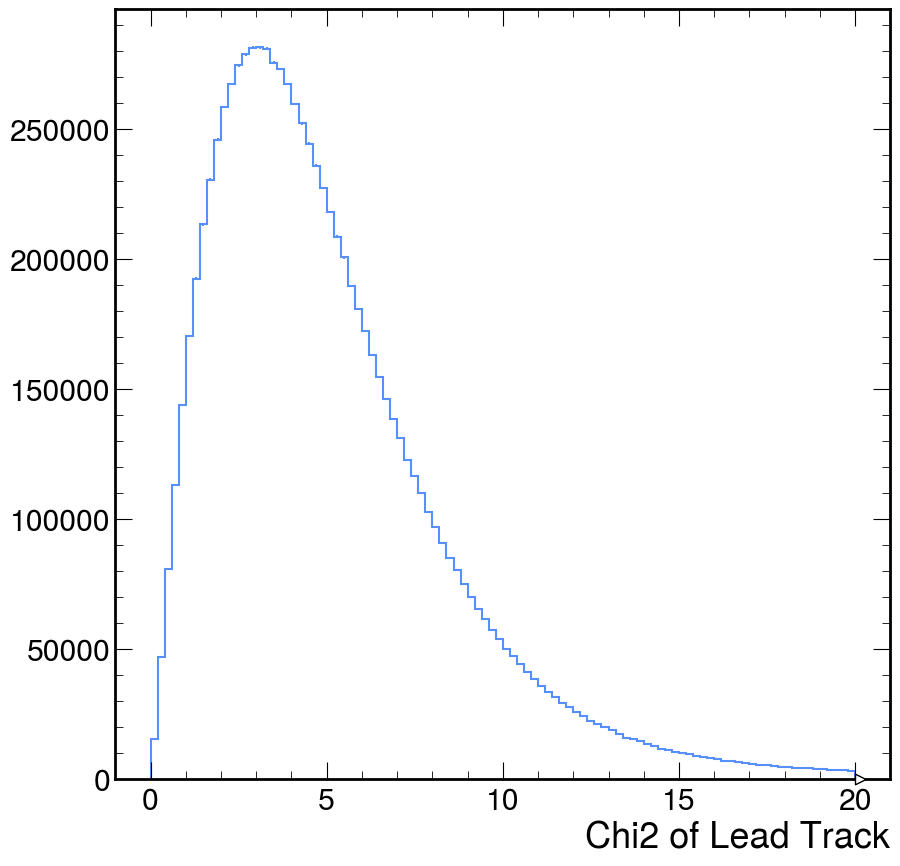

In [23]:
f['leadtrk_chi2'].to_hist().plot()
#plt.yscale("log")
#plt.savefig("leadtrk_chi2_zoom.jpg")

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fad714245c0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

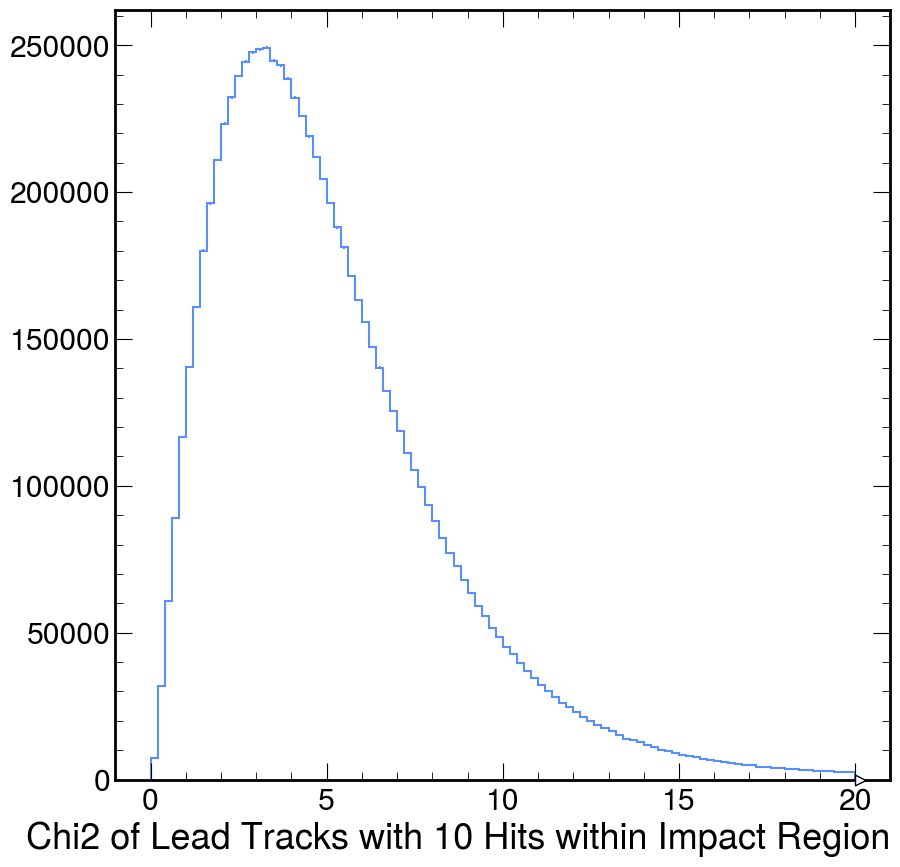

In [24]:
f['leadtrk_chi2_nhits_10_impact_cuts'].to_hist().plot()

#plt.savefig("leadtrk_chi2_nhits_10_impact_cuts_zoom.jpg")

Text(0.5, 1.0, 'Leading Tracks with Impact Point Cuts')

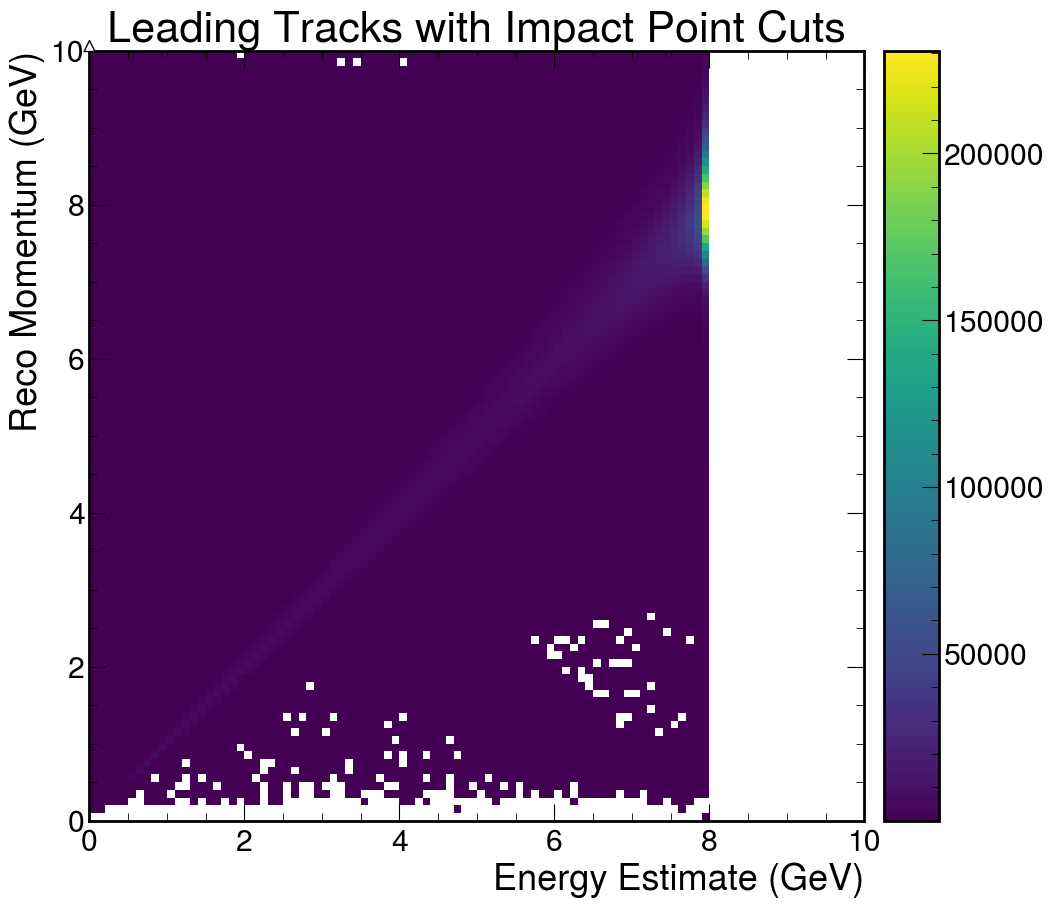

In [77]:
f['leadtrk_reco_vs_sim_momentum_impact_cuts'].to_hist().plot(cmin=1)
plt.title("Leading Tracks with Impact Point Cuts")

#plt.savefig("leadtrk_reco_vs_sim_momentum_impact_cuts.jpg")

Text(0.5, 1.0, 'Leading Tracks with 10 Hits - Impact Point Cuts')

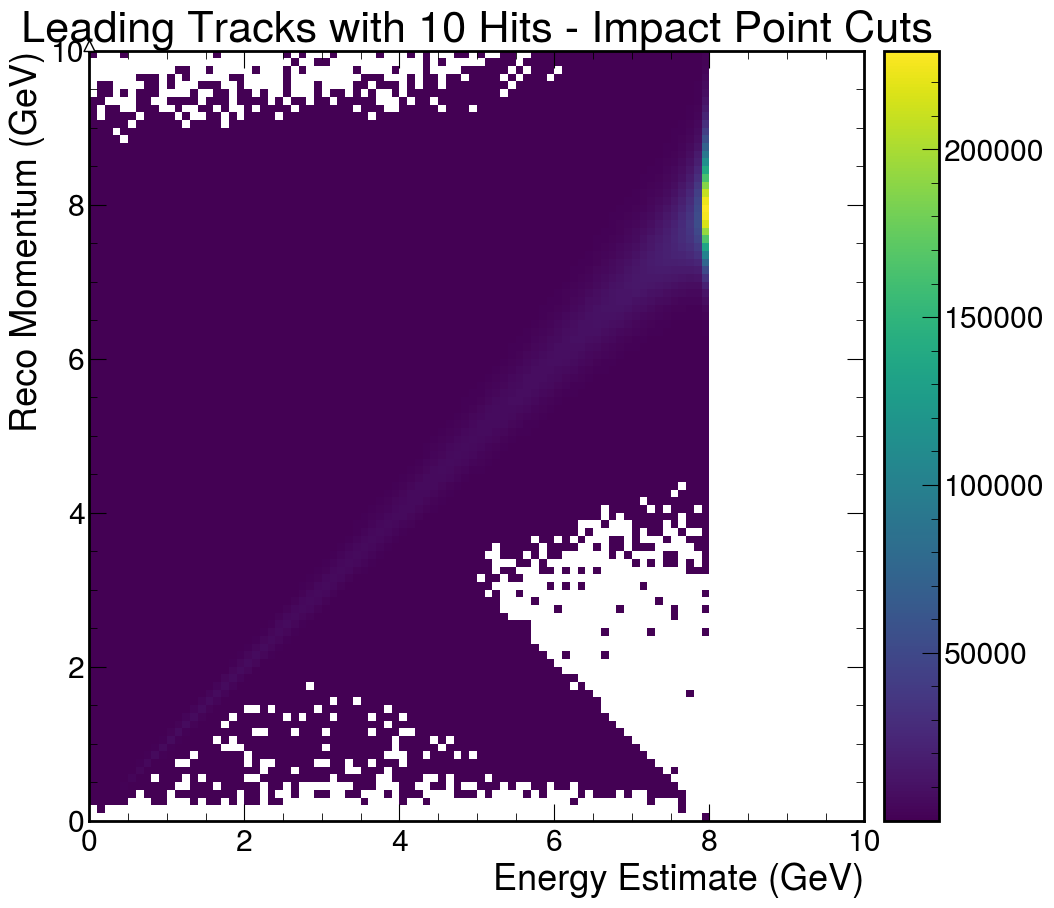

In [76]:
f['leadtrk_reco_vs_sim_momentum_nhits_10_impact_cuts'].to_hist().plot(cmin=1)
plt.title("Leading Tracks with 10 Hits - Impact Point Cuts")

#plt.savefig("leadtrk_reco_vs_sim_momentum_nhits_10_impact_cuts.jpg")